In [6]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [7]:
# Load Dataset
df = pd.read_csv("Housing.csv")

print("First Five Rows")
print(df.head())

First Five Rows
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


Display dataset information:

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


Check shape:

In [9]:
print(df.shape)

(545, 13)


Check Missing Values

In [10]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Suppose bedrooms contains missing values.

Fill with median:

In [11]:
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_10476\2616886916.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)


0      4
1      4
2      3
3      4
4      4
      ..
540    2
541    3
542    2
543    3
544    3
Name: bedrooms, Length: 545, dtype: int64

Check again:

In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Check Duplicate Records

In [13]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


Remove duplicates:

In [ ]:
df = df.drop_duplicates()

Save Cleaned Dataset

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)
print("cleaned_dataset.csv saved successfully")

cleaned_dataset.csv saved successfully


Basic Statistics

In [19]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Find average price:

In [ ]:
print("Average Price =", df['price'].mean())s

Average Price = 4766729.247706422


Maximum price:

In [ ]:
print("Maximum Price =", df['price'].max())

Maximum Price = 13300000


Minimum price:

In [ ]:
print("Minimum Price =", df['price'].min())s

Minimum Price = 1750000


Price Distribution

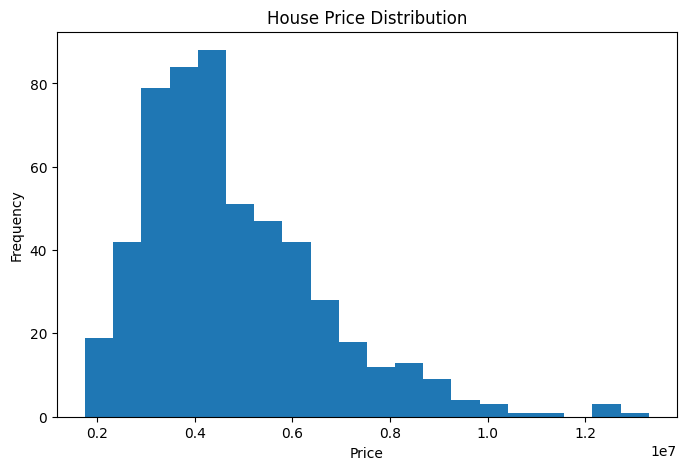

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Bedrooms vs Price

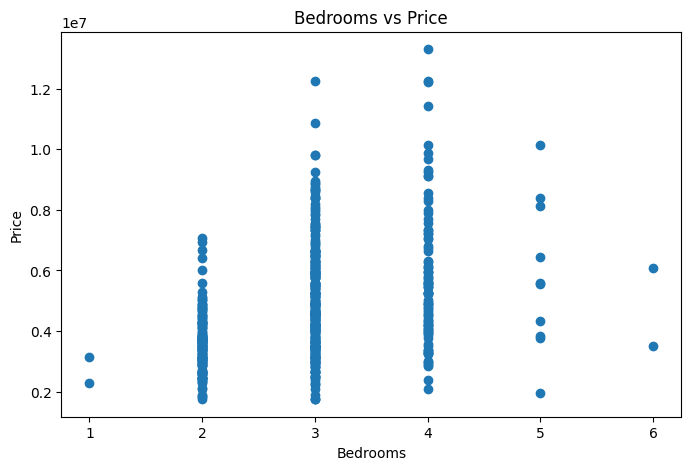

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(df['bedrooms'], df['price'])
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

Area vs Price

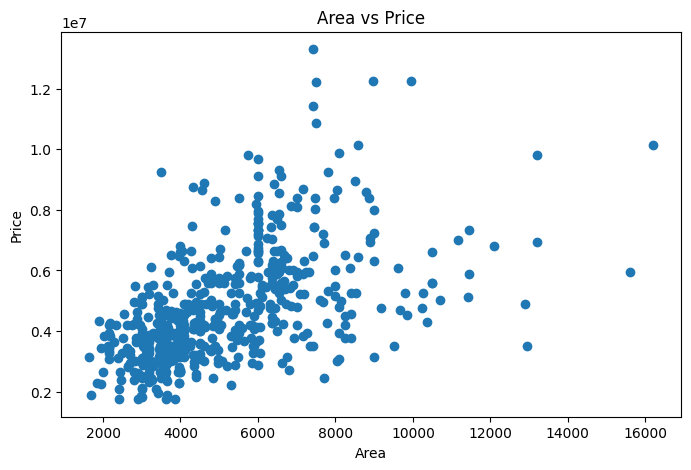

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

Correlation Analysis

In [26]:
correlation = df.corr(numeric_only=True)
print(correlation)

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


In [ ]:
print(correlation['price'].sort_values(ascending=False))s

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


inal Conclusions

Add a markdown cell:

Conclusion:

1. Missing values were handled.
2. Duplicate records were removed.
3. Larger houses tend to have higher prices.
4. Houses with more bedrooms generally cost more.
5. Area has a strong positive relationship with price.
6. Cleaned dataset was saved as cleaned_dataset.csv.